In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import sys
import gc
import numpy as np
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers, models, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger, EarlyStopping
import matplotlib.pyplot as plt
from sklearn.utils import shuffle

2026-01-22 23:15:13.668511: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-22 23:15:13.684752: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-22 23:15:13.689398: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
%load_ext autoreload
%autoreload 2

# Pega o diretório atual e sobe um nível ('..')
project_root = os.path.abspath('..')

# Adiciona este diretório ao sys.path se ele ainda não estiver lá
if project_root not in sys.path:
    sys.path.append(project_root)

# --- Seus imports originais ---
import utils.processamento_dados as proc_dados
import utils.metricas_e_visualizacao as met_vil

In [3]:
# --- 2. CONFIGURAÇÕES DE AMBIENTE E CAMINHOS ---
# Configuração básica de GPU (Memory Growth) para evitar alocação total imediata
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

I0000 00:00:1769134617.211945 1010255 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1769134617.214585 1010255 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1769134617.214620 1010255 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.


In [4]:
# DEFINA SEUS CAMINHOS AQUI:
BASE_DIR = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI"

data_dir_train = f"{BASE_DIR}/ADNI_NORMALIZED/train"
data_dir_val = f"{BASE_DIR}/ADNI_NORMALIZED/validation"
data_dir_test = f"{BASE_DIR}/ADNI_NORMALIZED/test"

data_3t_dir = os.path.join(BASE_DIR, "ADNI_3_4_NORMALIZED")
results_dir = os.path.join(BASE_DIR, "results", "full_fine_tuning_3t_k_fold")
os.makedirs(results_dir, exist_ok=True)

adni_class_names = ['cn', 'ad']

In [5]:
n = len(os.listdir(results_dir))

folder_name = f"test_{str(n+1)}_4_camadas"
results_dir = os.path.join(results_dir, folder_name)
os.makedirs(results_dir, exist_ok=True)
print(f"pasta {folder_name} criada")

pre_results_dir = f"{results_dir}/pre"
os.makedirs(pre_results_dir, exist_ok=True)
post_results_dir = f"{results_dir}/post"
os.makedirs(post_results_dir, exist_ok=True)

pasta test_7_4_camadas criada


In [6]:
# Nome do modelo pré-treinado (Treinado no dataset 1.5T)
# pretrained_model_path = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/results_fit_15_predict_3/test_1/binary_classifier_noise_200_epochs_batch_15_2_classes.keras"

def create_model_3d(input_shape, n_classes):
    # Entrada
    inputs = Input(shape=input_shape)  # (D, H, W, C)

    # === Camada 1 ===
    x = layers.Conv3D(2, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
    # x = layers.Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(4, 4, 4), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # === Camada 2 ===
    x = layers.Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    # x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # === Camada 3 ===
    x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    # x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # === Camada 4 ===
    x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    # x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)


    # === Classificador ===
    x = layers.Flatten()(x)

    x = layers.Dense(16, kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    # === Adaptação da Saída ===
    if n_classes == 2:
        # Binário: 1 neurônio com Sigmoid (para funcionar com binary_crossentropy)
        outputs = layers.Dense(1, activation='sigmoid')(x)
    else:
        # Multiclasse: N neurônios com Softmax
        outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="Small_Leaky_3D_Model")
    
    return model

## Pré-treinamento

In [7]:
# --- FLUXO PRINCIPAL (Carregamento Simples sem Augmentation) ---

# 2. Carregar Dados diretamente de cada pasta
print(f"Carregando dados de Treino de: {data_dir_train} ...")
X_train_final, y_train_final = proc_dados.load_nifti_data(data_dir_train)

print(f"Carregando dados de Validação de: {data_dir_val} ...")
X_val, y_val = proc_dados.load_nifti_data(data_dir_val)

# Verificação básica
if len(X_train_final) == 0:
    print("ERRO: Nenhum dado de treino encontrado. Verifique se a pasta 'train' existe e contém imagens.")
else:
    
    # X_train_final, y_train_final = shuffle(X_train_final, y_train_final, random_state=42)

    print(f"\n--- Resultado Final (Sem Augmentation) ---")
    print(f"Treino:     {X_train_final.shape}")
    print(f"Validação:  {X_val.shape}")

Carregando dados de Treino de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/train ...
Mapeando arquivos em: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/train
Embaralhando 1064 caminhos de arquivos...
Iniciando carregamento das imagens...


Carregando NifTI: 100%|██████████| 1064/1064 [10:26<00:00,  1.70it/s]


Convertendo lista para array numpy...
Dados carregados e embaralhados. Shape: (1064, 156, 195, 160, 1)
Carregando dados de Validação de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/validation ...
Mapeando arquivos em: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/validation
Embaralhando 289 caminhos de arquivos...
Iniciando carregamento das imagens...


Carregando NifTI: 100%|██████████| 289/289 [00:48<00:00,  5.90it/s]


Convertendo lista para array numpy...
Dados carregados e embaralhados. Shape: (289, 156, 195, 160, 1)

--- Resultado Final (Sem Augmentation) ---
Treino:     (1064, 156, 195, 160, 1)
Validação:  (289, 156, 195, 160, 1)


In [8]:
# Instancia o novo modelo
model = create_model_3d(input_shape=X_train_final[0].shape, n_classes=2)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='binary_crossentropy', 
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

I0000 00:00:1769135465.021704 1010255 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1769135465.028228 1010255 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1769135465.028259 1010255 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1769135465.810706 1010255 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1769135465.815299 1010255 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Model: "Small_Leaky_3D_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 156, 195, 160,  │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 156, 195, 160,  │            56 │
│                                 │ 2)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 156, 195, 160,  │             8 │
│ (BatchNormalization)            │ 2)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 156, 195, 160,  │             0 │
│                                 │ 2)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d               │ (None, 39, 49, 40, 2)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 39, 49, 40, 2)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 39, 49, 40, 4)  │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 39, 49, 40, 4)  │            16 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 39, 49, 40, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_1             │ (None, 13, 17, 14, 4)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 17, 14, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 13, 17, 14, 8)  │           872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 13, 17, 14, 8)  │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 13, 17, 14, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_2             │ (None, 5, 6, 5, 8)     │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 6, 5, 8)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_3 (Conv3D)               │ (None, 5, 6, 5, 16)    │         3,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 5, 6, 5, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 5, 6, 5, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_3             │ (None, 2, 2, 2, 16)    │             

 Total params: 6,885 (26.89 KB)

 Trainable params: 6,793 (26.54 KB)

 Non-trainable params: 92 (368.00 B)

In [9]:
batch_size = 8

steps_per_epoch = len(X_train_final) // batch_size
validation_steps = len(X_val) // batch_size

epochs = 150

new_model_name_ker = (f"binary_classifier_noise_{epochs}_epochs_batch_{batch_size}_{2}_classes.keras")

# Parar caso fique {patience} épocas sem melhora
early_stopping = EarlyStopping(
    restore_best_weights=True,
    monitor='val_accuracy',     
    patience=20,                 
    verbose=1
)

# # Defina o nome do arquivo para salvar o melhor modelo
model_checkpoint_callback = ModelCheckpoint(
    filepath=os.path.join(pre_results_dir, new_model_name_ker),    
    monitor='val_accuracy',
    save_best_only=True, 
    mode='max', 
)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1)

log_path = os.path.join(pre_results_dir, 'log_treino_ruido.csv')
csv_log = CSVLogger(log_path, append=False)

In [10]:
# Forçar coleta de lixo para liberar qualquer memória residual antes de começar
gc.collect()

# Ela pega os dados diretamente das suas variáveis globais X_train_final e y_train_final
def train_gen():
    for i in range(len(X_train_final)):
        yield X_train_final[i], y_train_final[i]

def val_gen():
    for i in range(len(X_val)):
        yield X_val[i], y_val[i]

output_signature = (
    tf.TensorSpec(shape=(156, 195, 160, 1), dtype=tf.float16),
    tf.TensorSpec(shape=(), dtype=tf.int16)               
)

# --- Criação dos Datasets ---
print("Criando Dataset de Treino via Generator...")
train_dataset = tf.data.Dataset.from_generator(
    train_gen,
    output_signature=output_signature
)

# Agora aplicamos batch e prefetch
train_dataset = train_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("Criando Dataset de Validação via Generator...")
val_dataset = tf.data.Dataset.from_generator(
    val_gen,
    output_signature=output_signature
)
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

Criando Dataset de Treino via Generator...
Criando Dataset de Validação via Generator...


In [11]:
# 3. Treinamento usando o Dataset
history = model.fit(
    train_dataset,  
    epochs=epochs,
    verbose=1,
    validation_data=val_dataset,
    callbacks=[model_checkpoint_callback, csv_log, early_stopping]
)

Epoch 1/150


I0000 00:00:1769135491.046289   57035 service.cc:146] XLA service 0x7f8098003420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769135491.046351   57035 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-01-22 23:31:38.222769: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng26{k2=0,k13=2,k14=3,k18=0,k22=0,k23=0} for conv (f32[8,2,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[8,1,156,195,160]{4,3,2,1,0}, f32[2,1,3,3,3]{4,3,2,1,0}, f32[2]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-01-22 23:31:40.939784: E external/local_xl

    133/Unknown 53s 156ms/step - accuracy: 0.5147 - auc: 0.4840 - loss: 1.3341

/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
2026-01-22 23:32:28.914662: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %reduce-window.159 = f32[1,39,49,40,2]{4,3,2,1,0} reduce-window(f32[1,156,195,160,2]{4,3,2,1,0} %broadcast.148, f32[] %constant.149), window={size=1x4x4x4x1 stride=1x4x4x4x1 pad=0_0x0_0x0_1x0_0x0_0}, to_apply=%region_1.155, metadata={op_type="AvgPool3D" op_name="Small_Leaky_3D_Model_1/average_pooling3d_1/AvgPool3D"}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has

133/133 ━━━━━━━━━━━━━━━━━━━━ 64s 238ms/step - accuracy: 0.5442 - auc: 0.5458 - loss: 1.2338 - val_accuracy: 0.5260 - val_auc: 0.8392 - val_loss: 1.0861
Epoch 2/150
133/133 ━━━━━━━━━━━━━━━━━━━━ 26s 195ms/step - accuracy: 0.5235 - auc: 0.5434 - loss: 1.1124 - val_accuracy: 0.5052 - val_auc: 0.8617 - val_loss: 1.0283
Epoch 3/150
133/133 ━━━━━━━━━━━━━━━━━━━━ 26s 193ms/step - accuracy: 0.5836 - auc: 0.6011 - loss: 1.0082 - val_accuracy: 0.5121 - val_auc: 0.8605 - val_loss: 0.9572
Epoch 4/150
133/133 ━━━━━━━━━━━━━━━━━━━━ 26s 193ms/step - accuracy: 0.5630 - auc: 0.5813 - loss: 0.9646 - val_accuracy: 0.6782 - val_auc: 0.8641 - val_loss: 0.8140
Epoch 5/150
133/133 ━━━━━━━━━━━━━━━━━━━━ 27s 201ms/step - accuracy: 0.6053 - auc: 0.6264 - loss: 0.8966 - val_accuracy: 0.5260 - val_auc: 0.7930 - val_loss: 1.1814
Epoch 6/150
133/133 ━━━━━━━━━━━━━━━━━━━━ 26s 196ms/step - accuracy: 0.5789 - auc: 0.6109 - loss: 0.8661 - val_accuracy: 0.5260 - val_auc: 0.8535 - val_loss: 1.5481
Epoch 7/150
133/133 ━━━━━━━━

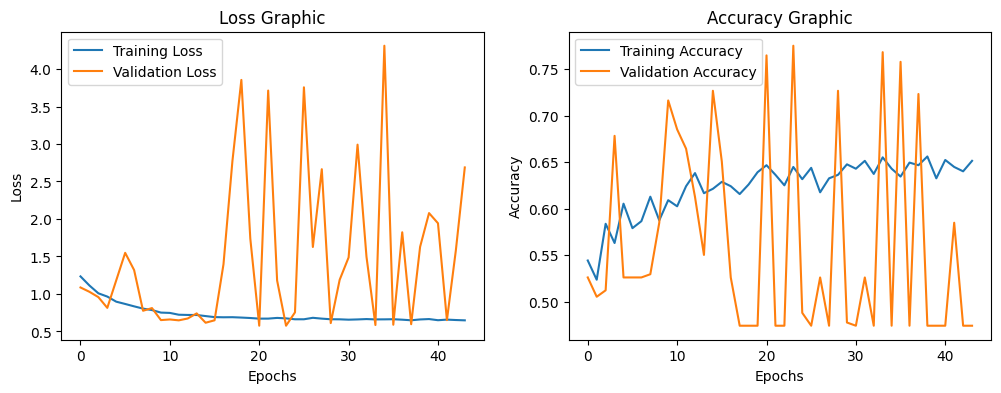

In [12]:
# Plotando o histórico de treinamento após o treinamento
met_vil.plot_training_history_binary(history, f"{pre_results_dir}")

#### Predição validação e teste

              precision    recall  f1-score   support

           0       0.71      0.88      0.79       137
           1       0.86      0.68      0.76       152

    accuracy                           0.78       289
   macro avg       0.79      0.78      0.77       289
weighted avg       0.79      0.78      0.77       289



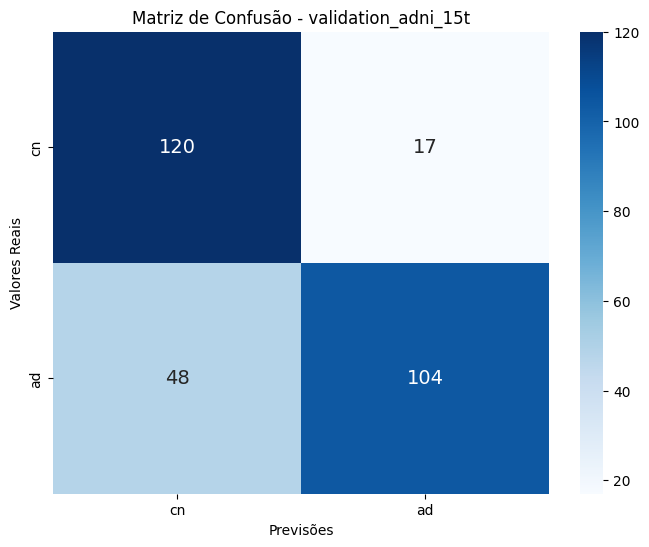

In [13]:
# Realizar predições para dados do conjunto validação
val_pred_labels, val_true_labels, val_pred = met_vil.get_predictions_binary(X_val, y_val, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(val_true_labels, val_pred_labels, pre_results_dir, 'validation_adni_15t')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(val_true_labels, val_pred_labels, pre_results_dir, 'validation_adni_15t', adni_class_names)

Carregando dados de Teste de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/test ...
Mapeando arquivos em: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/test
Embaralhando 150 caminhos de arquivos...
Iniciando carregamento das imagens...


Carregando NifTI: 100%|██████████| 150/150 [00:23<00:00,  6.30it/s]


Convertendo lista para array numpy...
Dados carregados e embaralhados. Shape: (150, 156, 195, 160, 1)
Teste:      (150, 156, 195, 160, 1)


2026-01-22 23:52:32.352585: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng26{k2=0,k13=2,k14=3,k18=0,k22=0,k23=0} for conv (f32[6,2,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[6,1,156,195,160]{4,3,2,1,0}, f32[2,1,3,3,3]{4,3,2,1,0}, f32[2]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-01-22 23:52:32.400723: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.048227042s
Trying algorithm eng26{k2=0,k13=2,k14=3,k18=0,k22=0,k23=0} for conv (f32[6,2,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[6,1,156,195,160]{4,3,2,1,0}, f32[2,1,3,3,3]{4,3,2,1,0}, f32[2]{0}), window={size=3x3x3 pad=1_1x1_

              precision    recall  f1-score   support

           0       0.61      0.75      0.67        73
           1       0.70      0.55      0.61        77

    accuracy                           0.65       150
   macro avg       0.66      0.65      0.64       150
weighted avg       0.66      0.65      0.64       150



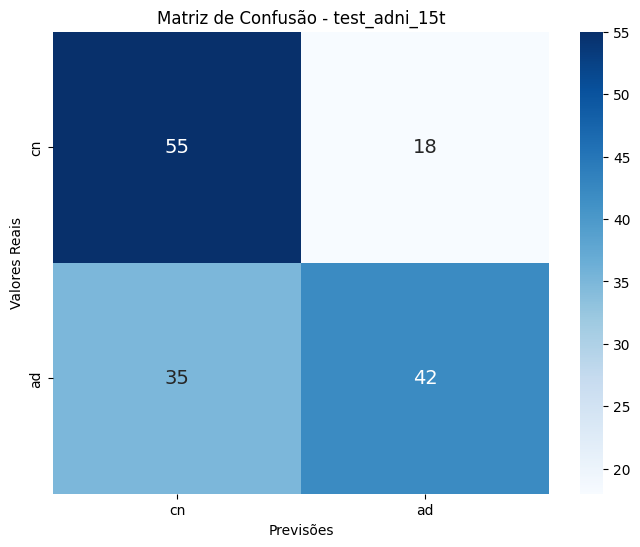

In [14]:
print(f"Carregando dados de Teste de: {data_dir_test} ...")
X_test, y_test = proc_dados.load_nifti_data(data_dir_test)
print(f"Teste:      {X_test.shape}")

# Realizar predições para dados do conjunto validação
test_pred_labels, test_true_labels, test_pred = met_vil.get_predictions_binary(X_test, y_test, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(test_true_labels, test_pred_labels, pre_results_dir, 'test_adni_15t')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(test_true_labels, test_pred_labels, pre_results_dir, 'test_adni_15t', adni_class_names)

#### Predição 3T

In [15]:
del X_train_final, y_train_final, X_val, y_val, X_test, y_test

In [16]:
# === 4. PREPARAÇÃO DOS DADOS 3T (União de todas as pastas) ===
print("--- Carregando e Unificando Dados 3T ---")

dir_3t_train = os.path.join(data_3t_dir, "train")
dir_3t_val = os.path.join(data_3t_dir, "validation")
dir_3t_test = os.path.join(data_3t_dir, "test")

parts_X = []
parts_y = []

# Carrega tudo usando a função do seu módulo local
for d in [dir_3t_train, dir_3t_val, dir_3t_test]:
    print(f"Lendo pasta: {d}")
    try:
        x_part, y_part = proc_dados.load_nifti_data(d)
        if len(x_part) > 0:
            parts_X.append(x_part)
            parts_y.append(y_part)
    except Exception as e:
        print(f"Erro ao ler pasta {d}: {e}")

if len(parts_X) > 0:
    X_3t_all = np.concatenate(parts_X, axis=0)
    y_3t_all = np.concatenate(parts_y, axis=0)
    print(f"Total de dados 3T para K-Fold: {X_3t_all.shape}")
else:
    raise ValueError("Não foram encontrados dados nas pastas 3T.")

--- Carregando e Unificando Dados 3T ---
Lendo pasta: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/train
Mapeando arquivos em: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/train
Embaralhando 699 caminhos de arquivos...
Iniciando carregamento das imagens...


Carregando NifTI: 100%|██████████| 699/699 [01:54<00:00,  6.11it/s]


Convertendo lista para array numpy...
Dados carregados e embaralhados. Shape: (699, 156, 195, 160, 1)
Lendo pasta: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/validation
Mapeando arquivos em: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/validation
Embaralhando 202 caminhos de arquivos...
Iniciando carregamento das imagens...


Carregando NifTI: 100%|██████████| 202/202 [00:30<00:00,  6.66it/s]


Convertendo lista para array numpy...
Dados carregados e embaralhados. Shape: (202, 156, 195, 160, 1)
Lendo pasta: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/test
Mapeando arquivos em: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/test
Embaralhando 102 caminhos de arquivos...
Iniciando carregamento das imagens...


Carregando NifTI: 100%|██████████| 102/102 [00:15<00:00,  6.40it/s]


Convertendo lista para array numpy...
Dados carregados e embaralhados. Shape: (102, 156, 195, 160, 1)
Total de dados 3T para K-Fold: (1003, 156, 195, 160, 1)


2026-01-22 23:56:26.756354: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 2s:

  %reduce-window.100 = f32[3,39,49,40,2]{4,3,2,1,0} reduce-window(f32[3,156,195,160,2]{4,3,2,1,0} %broadcast.89, f32[] %constant.90), window={size=1x4x4x4x1 stride=1x4x4x4x1 pad=0_0x0_0x0_1x0_0x0_0}, to_apply=%region_1.96, metadata={op_type="AvgPool3D" op_name="Small_Leaky_3D_Model_1/average_pooling3d_1/AvgPool3D"}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2026-01-22 23:56:29.836893: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 5.080692957s
Constant folding an in

              precision    recall  f1-score   support

           0       0.92      0.78      0.84       875
           1       0.25      0.52      0.34       128

    accuracy                           0.74      1003
   macro avg       0.58      0.65      0.59      1003
weighted avg       0.83      0.74      0.78      1003



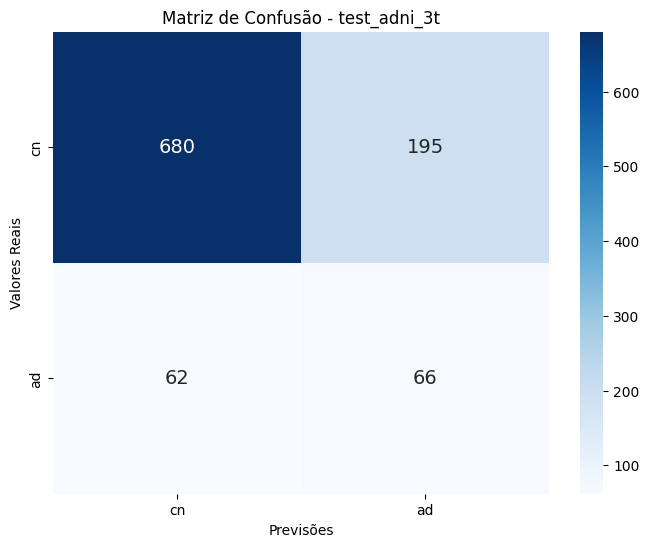

In [17]:
# Realizar predições para dados do conjunto validação
test_pred_labels, test_true_labels, test_pred = met_vil.get_predictions_binary(X_3t_all, y_3t_all, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(test_true_labels, test_pred_labels, pre_results_dir, 'test_adni_3t')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(test_true_labels, test_pred_labels, pre_results_dir, 'test_adni_3t', adni_class_names)

## Fine Tunning

In [18]:
# === 5. CONFIGURAÇÃO DO K-FOLD E MODELO ===
K_FOLDS = 5
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

# Listas para armazenar métricas de cada fold
fold_accuracies = []
fold_aucs = []

all_true_labels = []
all_pred_labels = []

print(f"\n>>> INICIANDO FINE-TUNING (K-FOLD = {K_FOLDS}) <<<")


>>> INICIANDO FINE-TUNING (K-FOLD = 5) <<<


In [ ]:
BATCH_SIZE = 8
EPOCHS = 50
K_FOLDS = 5
LEARNING_RATE = 0.001

# Garante que o K-Fold está definido
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

: 


INICIANDO FOLD 1/5 (FINE-TUNING COM AUGMENTATION)
Gerando Augmentation e Balanceamento na RAM...
    > Balanceamento: Majoritária (0): 700 | Minoritária (1): 102
    > Alocando memória para 1312 amostras (float16). Shape final: (1312, 156, 195, 160, 1)
    Processando: 800/802...
Dados Augmentados na RAM! Shape: (1312, 156, 195, 160, 1)
Configurando tf.data Generators...
   Congelando camadas iniciais (0 a 5)...
<InputLayer name=input_layer, built=True> congelada!
<Conv3D name=conv3d, built=True> congelada!
<BatchNormalization name=batch_normalization, built=True> congelada!
<LeakyReLU name=leaky_re_lu, built=True> congelada!
<AveragePooling3D name=average_pooling3d, built=True> congelada!
🚀 Iniciando Fine-Tuning...
Epoch 1/50
    164/Unknown 68s 327ms/step - accuracy: 0.6713 - auc: 0.7262 - loss: 0.6475

/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


164/164 ━━━━━━━━━━━━━━━━━━━━ 78s 389ms/step - accuracy: 0.6669 - auc: 0.7278 - loss: 0.6384 - val_accuracy: 0.2040 - val_auc: 0.7229 - val_loss: 0.9805
Epoch 2/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 56s 338ms/step - accuracy: 0.6768 - auc: 0.7336 - loss: 0.6327 - val_accuracy: 0.1542 - val_auc: 0.7300 - val_loss: 1.1573
Epoch 3/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 60s 367ms/step - accuracy: 0.6875 - auc: 0.7501 - loss: 0.6206 - val_accuracy: 0.6667 - val_auc: 0.7300 - val_loss: 0.6617
Epoch 4/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 54s 327ms/step - accuracy: 0.6860 - auc: 0.7352 - loss: 0.6330 - val_accuracy: 0.1294 - val_auc: 0.6982 - val_loss: 1.5763
Epoch 5/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 55s 336ms/step - accuracy: 0.6814 - auc: 0.7606 - loss: 0.6131 - val_accuracy: 0.8607 - val_auc: 0.7297 - val_loss: 0.4372
Epoch 6/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 55s 334ms/step - accuracy: 0.6837 - auc: 0.7576 - loss: 0.6164 - val_accuracy: 0.2289 - val_auc: 0.7296 - val_loss: 0.9464
Epoch 7/50
164/164 ━━━━━━━━━━━━━━

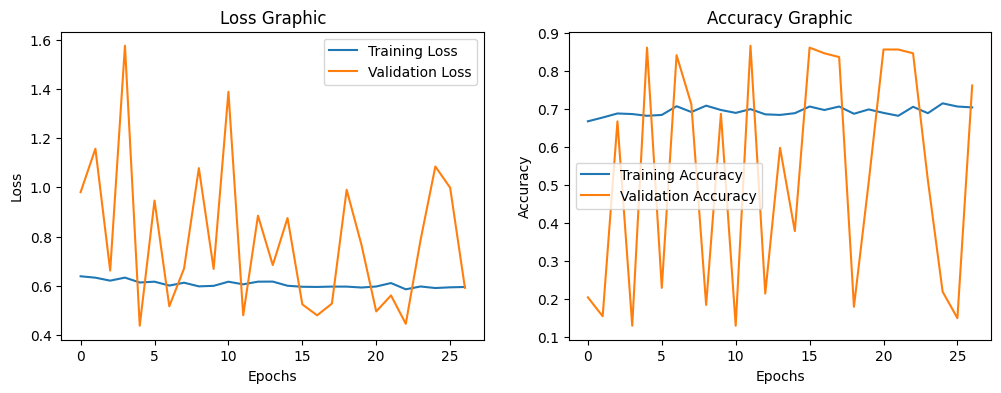

Carregando melhor modelo do fold para avaliação...
   Resultado Fold 1: Acc=0.8657, AUC=0.7291
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       175
           1       0.00      0.00      0.00        26

    accuracy                           0.87       201
   macro avg       0.43      0.50      0.46       201
weighted avg       0.76      0.87      0.81       201



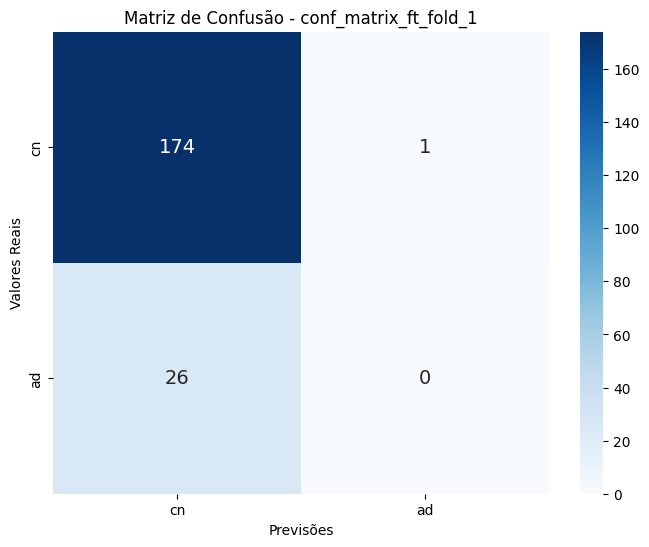

🧹 Limpando memória...

INICIANDO FOLD 2/5 (FINE-TUNING COM AUGMENTATION)
Gerando Augmentation e Balanceamento na RAM...
    > Balanceamento: Majoritária (0): 700 | Minoritária (1): 102
    > Alocando memória para 1312 amostras (float16). Shape final: (1312, 156, 195, 160, 1)
    Processando: 800/802...
Dados Augmentados na RAM! Shape: (1312, 156, 195, 160, 1)
Configurando tf.data Generators...
   Congelando camadas iniciais (0 a 5)...
<InputLayer name=input_layer, built=True> congelada!
<Conv3D name=conv3d, built=True> congelada!
<BatchNormalization name=batch_normalization, built=True> congelada!
<LeakyReLU name=leaky_re_lu, built=True> congelada!
<AveragePooling3D name=average_pooling3d, built=True> congelada!
🚀 Iniciando Fine-Tuning...
Epoch 1/50
    164/Unknown 58s 306ms/step - accuracy: 0.7301 - auc: 0.7805 - loss: 0.6005

/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


164/164 ━━━━━━━━━━━━━━━━━━━━ 66s 359ms/step - accuracy: 0.7157 - auc: 0.7748 - loss: 0.6014 - val_accuracy: 0.5075 - val_auc: 0.7033 - val_loss: 0.7719
Epoch 2/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 53s 322ms/step - accuracy: 0.7210 - auc: 0.7823 - loss: 0.5955 - val_accuracy: 0.7761 - val_auc: 0.7498 - val_loss: 0.5309
Epoch 3/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 52s 316ms/step - accuracy: 0.7043 - auc: 0.7697 - loss: 0.6028 - val_accuracy: 0.1294 - val_auc: 0.6347 - val_loss: 1.0128
Epoch 4/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 51s 312ms/step - accuracy: 0.7096 - auc: 0.7833 - loss: 0.5915 - val_accuracy: 0.6368 - val_auc: 0.7335 - val_loss: 0.6602
Epoch 5/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 52s 315ms/step - accuracy: 0.6890 - auc: 0.7683 - loss: 0.6037 - val_accuracy: 0.8657 - val_auc: 0.7671 - val_loss: 0.3866
Epoch 6/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 52s 315ms/step - accuracy: 0.7271 - auc: 0.7909 - loss: 0.5894 - val_accuracy: 0.5174 - val_auc: 0.7201 - val_loss: 0.7920
Epoch 7/50
164/164 ━━━━━━━━━━━━━━

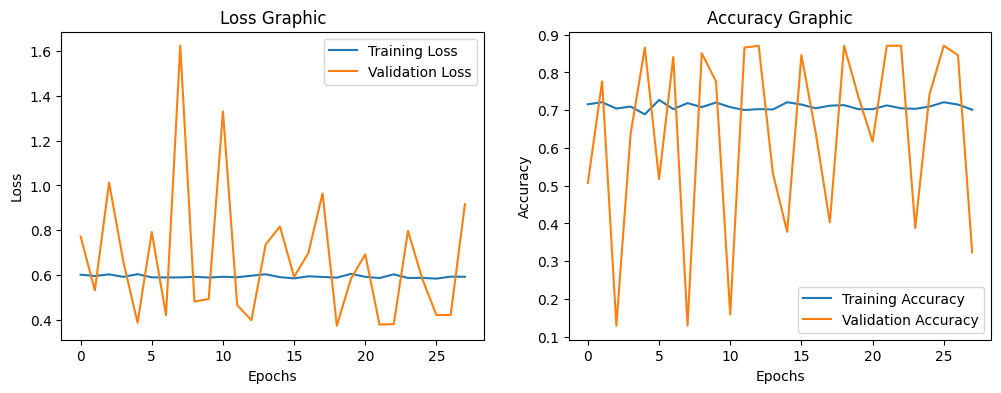

Carregando melhor modelo do fold para avaliação...
   Resultado Fold 2: Acc=0.8706, AUC=0.7660


/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no

              precision    recall  f1-score   support

           0       0.87      1.00      0.93       175
           1       0.00      0.00      0.00        26

    accuracy                           0.87       201
   macro avg       0.44      0.50      0.47       201
weighted avg       0.76      0.87      0.81       201



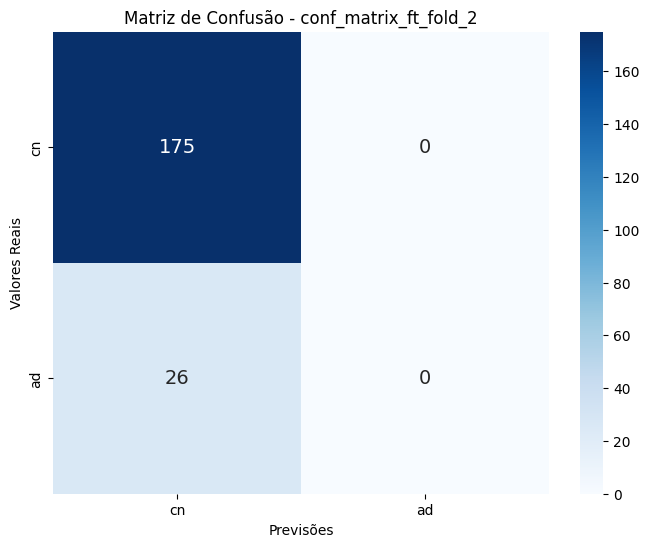

🧹 Limpando memória...

INICIANDO FOLD 3/5 (FINE-TUNING COM AUGMENTATION)
Gerando Augmentation e Balanceamento na RAM...
    > Balanceamento: Majoritária (0): 700 | Minoritária (1): 102
    > Alocando memória para 1312 amostras (float16). Shape final: (1312, 156, 195, 160, 1)
    Processando: 800/802...
Dados Augmentados na RAM! Shape: (1312, 156, 195, 160, 1)
Configurando tf.data Generators...
   Congelando camadas iniciais (0 a 5)...
<InputLayer name=input_layer, built=True> congelada!
<Conv3D name=conv3d, built=True> congelada!
<BatchNormalization name=batch_normalization, built=True> congelada!
<LeakyReLU name=leaky_re_lu, built=True> congelada!
<AveragePooling3D name=average_pooling3d, built=True> congelada!
🚀 Iniciando Fine-Tuning...
Epoch 1/50
    164/Unknown 59s 316ms/step - accuracy: 0.6973 - auc: 0.7530 - loss: 0.6307

/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


164/164 ━━━━━━━━━━━━━━━━━━━━ 68s 368ms/step - accuracy: 0.6966 - auc: 0.7618 - loss: 0.6154 - val_accuracy: 0.1592 - val_auc: 0.7060 - val_loss: 1.0779
Epoch 2/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 54s 327ms/step - accuracy: 0.7104 - auc: 0.7785 - loss: 0.6012 - val_accuracy: 0.4826 - val_auc: 0.7503 - val_loss: 0.7458
Epoch 3/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 53s 324ms/step - accuracy: 0.7027 - auc: 0.7804 - loss: 0.5917 - val_accuracy: 0.1294 - val_auc: 0.7134 - val_loss: 1.1954
Epoch 4/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 53s 323ms/step - accuracy: 0.6791 - auc: 0.7596 - loss: 0.6064 - val_accuracy: 0.2040 - val_auc: 0.7453 - val_loss: 1.0398
Epoch 5/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 53s 321ms/step - accuracy: 0.7111 - auc: 0.7715 - loss: 0.6018 - val_accuracy: 0.6020 - val_auc: 0.7333 - val_loss: 0.6607
Epoch 6/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 54s 329ms/step - accuracy: 0.7012 - auc: 0.7665 - loss: 0.6013 - val_accuracy: 0.8706 - val_auc: 0.7780 - val_loss: 0.4502
Epoch 7/50
164/164 ━━━━━━━━━━━━━━

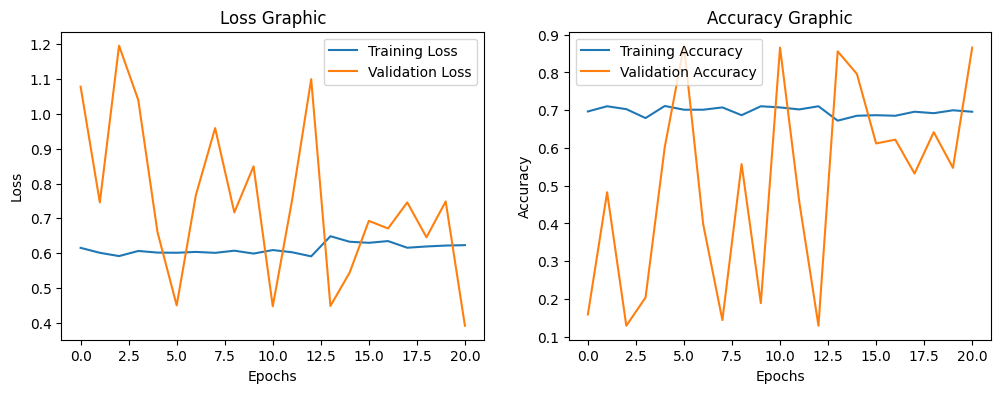

Carregando melhor modelo do fold para avaliação...
   Resultado Fold 3: Acc=0.8706, AUC=0.7780
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       175
           1       0.50      0.27      0.35        26

    accuracy                           0.87       201
   macro avg       0.70      0.61      0.64       201
weighted avg       0.85      0.87      0.85       201



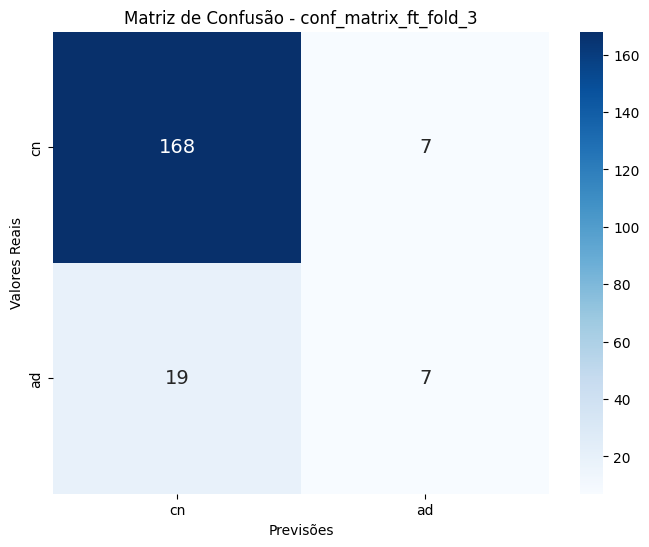

🧹 Limpando memória...

INICIANDO FOLD 4/5 (FINE-TUNING COM AUGMENTATION)
Gerando Augmentation e Balanceamento na RAM...
    > Balanceamento: Majoritária (0): 700 | Minoritária (1): 103
    > Alocando memória para 1318 amostras (float16). Shape final: (1318, 156, 195, 160, 1)
    Processando: 800/803...
Dados Augmentados na RAM! Shape: (1318, 156, 195, 160, 1)
Configurando tf.data Generators...
   Congelando camadas iniciais (0 a 5)...
<InputLayer name=input_layer, built=True> congelada!
<Conv3D name=conv3d, built=True> congelada!
<BatchNormalization name=batch_normalization, built=True> congelada!
<LeakyReLU name=leaky_re_lu, built=True> congelada!
<AveragePooling3D name=average_pooling3d, built=True> congelada!
🚀 Iniciando Fine-Tuning...
Epoch 1/50
    165/Unknown 65s 350ms/step - accuracy: 0.6450 - auc: 0.7095 - loss: 0.6574

/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


165/165 ━━━━━━━━━━━━━━━━━━━━ 71s 386ms/step - accuracy: 0.6631 - auc: 0.7285 - loss: 0.6451 - val_accuracy: 0.8550 - val_auc: 0.7293 - val_loss: 0.4531
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 54s 324ms/step - accuracy: 0.6935 - auc: 0.7506 - loss: 0.6311 - val_accuracy: 0.7900 - val_auc: 0.7298 - val_loss: 0.4599
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 54s 328ms/step - accuracy: 0.7071 - auc: 0.7621 - loss: 0.6187 - val_accuracy: 0.6800 - val_auc: 0.7185 - val_loss: 0.6358
Epoch 4/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 55s 331ms/step - accuracy: 0.7117 - auc: 0.7604 - loss: 0.6207 - val_accuracy: 0.8350 - val_auc: 0.7371 - val_loss: 0.4178
Epoch 5/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 53s 321ms/step - accuracy: 0.6927 - auc: 0.7466 - loss: 0.6260 - val_accuracy: 0.5650 - val_auc: 0.7145 - val_loss: 0.7381
Epoch 6/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 54s 327ms/step - accuracy: 0.6980 - auc: 0.7523 - loss: 0.6258 - val_accuracy: 0.8700 - val_auc: 0.7261 - val_loss: 0.4146
Epoch 7/50
165/165 ━━━━━━━━━━━━━━

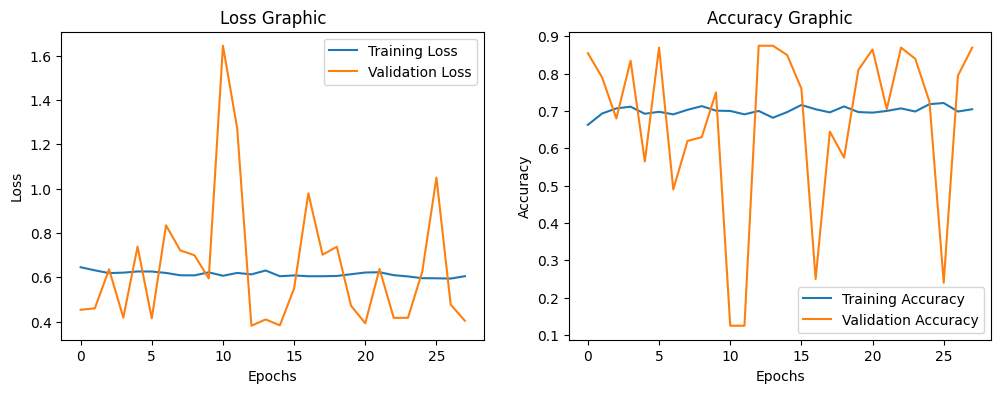

Carregando melhor modelo do fold para avaliação...
   Resultado Fold 4: Acc=0.8750, AUC=0.7355
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       175
           1       0.50      0.04      0.07        25

    accuracy                           0.88       200
   macro avg       0.69      0.52      0.50       200
weighted avg       0.83      0.88      0.83       200



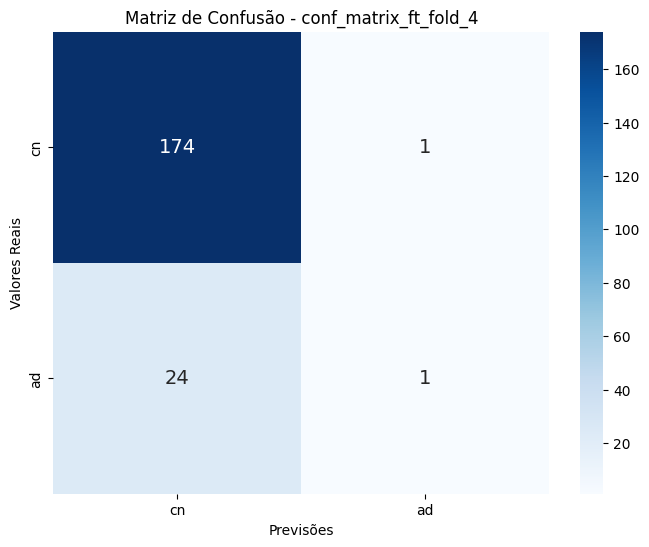

🧹 Limpando memória...

INICIANDO FOLD 5/5 (FINE-TUNING COM AUGMENTATION)
Gerando Augmentation e Balanceamento na RAM...
    > Balanceamento: Majoritária (0): 700 | Minoritária (1): 103
    > Alocando memória para 1318 amostras (float16). Shape final: (1318, 156, 195, 160, 1)
    Processando: 800/803...
Dados Augmentados na RAM! Shape: (1318, 156, 195, 160, 1)


In [ ]:
# Listas globais
fold_accuracies = []
fold_aucs = []
aggregated_true_labels = []
aggregated_pred_labels = []

# ==========================================
# 2. FUNÇÕES AUXILIARES (Augmentation & Generator)
# ==========================================

def augment_and_balance_in_ram(X_full, y_full, indices):
    # 1. Pega labels deste fold para contagem
    y_subset = y_full[indices]
    
    # 2. Identifica classe minoritária e majoritária
    counts = np.bincount(y_subset)
    minority_class = np.argmin(counts)
    majority_class = np.argmax(counts)
    n_minority = counts[minority_class]
    n_majority = counts[majority_class]
    
    print(f"    > Balanceamento: Majoritária ({majority_class}): {n_majority} | Minoritária ({minority_class}): {n_minority}")
    
    # 3. Calcula tamanho final
    # Antes era * 4 (Original + 3 Augs). 
    # Agora é * 6 (Original + 3 Augs Antigos + 1 Rot Extra + 1 Zoom Extra)
    total_final = n_majority + (n_minority * 6)
    
    # --- CORREÇÃO AQUI: Detecção Dinâmica de Shape ---
    sample_shape = X_full[0].shape
    
    # Se for (D, H, W), vira (D, H, W, 1). Se já for (D, H, W, C), mantém.
    if len(sample_shape) == 3:
        final_sample_shape = (*sample_shape, 1)
        needs_expansion = True # Indica que precisaremos expandir os originais
    else:
        final_sample_shape = sample_shape
        needs_expansion = False # Já tem canal

    final_shape = (total_final, *final_sample_shape)
    # -----------------------------------------------
    
    print(f"    > Alocando memória para {total_final} amostras (float16). Shape final: {final_shape}")
    
    # 4. Alocação
    try:
        X_aug = np.empty(final_shape, dtype=np.float16) 
        y_aug = np.empty((total_final,), dtype=np.int16)
    except MemoryError:
        print("ERRO FATAL: Memória RAM insuficiente para Augmentation.")
        raise
        
    # 5. Preenchimento e Augmentation
    cursor = 0
    total_indices = len(indices)
    
    # Função auxiliar interna para garantir shape correto vindo do augment
    def ensure_shape(img_aug):
        # Se a função de augment retornou 3D, expande.
        if len(img_aug.shape) == 3:
            return np.expand_dims(img_aug, axis=-1)
        # Se retornou 4D, verifica se bate com o target
        return img_aug

    for idx, i in enumerate(indices):
        orig = X_full[i] 
        lbl = y_full[i]
        
        # Prepara o original com o shape correto para inserção
        if needs_expansion:
            # (D, H, W) -> (D, H, W, 1)
            orig_ready = np.expand_dims(orig, axis=-1)
        else:
            # Já é (D, H, W, C)
            orig_ready = orig

        if lbl == majority_class:
            # Classe Majoritária: Copia apenas o original
            X_aug[cursor] = orig_ready
            y_aug[cursor] = lbl
            cursor += 1
        else:
            # Classe Minoritária: Original + 5 Augmentations
            
            # 1. Original
            X_aug[cursor] = orig_ready
            y_aug[cursor] = lbl
            cursor += 1
            
            # 2. Zoom (1)
            zoom_img = proc_dados.augment_zoom(orig) 
            X_aug[cursor] = ensure_shape(zoom_img)
            y_aug[cursor] = lbl
            cursor += 1
            
            # 3. Shift
            shift_img = proc_dados.augment_shift(orig)
            X_aug[cursor] = ensure_shape(shift_img)
            y_aug[cursor] = lbl
            cursor += 1
            
            # 4. Rotation (1)
            rot_img = proc_dados.augment_rotation(orig)
            X_aug[cursor] = ensure_shape(rot_img)
            y_aug[cursor] = lbl
            cursor += 1

            # 5. Rotation Extra (2)
            # Chama de novo para gerar uma rotação aleatória diferente
            rot_img_2 = proc_dados.augment_rotation(orig)
            X_aug[cursor] = ensure_shape(rot_img_2)
            y_aug[cursor] = lbl
            cursor += 1

            # 6. Zoom Extra (2)
            # Chama de novo para gerar um zoom aleatório diferente
            zoom_img_2 = proc_dados.augment_zoom(orig)
            X_aug[cursor] = ensure_shape(zoom_img_2)
            y_aug[cursor] = lbl
            cursor += 1
            
        if idx % 100 == 0:
            print(f"    Processando: {idx}/{total_indices}...", end='\r')
            
    print(f"\nDados Augmentados na RAM! Shape: {X_aug.shape}")
    
    # 6. Embaralhar
    shuf_idxs = np.arange(total_final)
    np.random.shuffle(shuf_idxs)
    
    return X_aug[shuf_idxs], y_aug[shuf_idxs]

def numpy_generator(x_data, y_data):
    for i in range(len(x_data)):
        yield x_data[i].astype(np.float32), y_data[i]

# LOOP PRINCIPAL
for fold_idx, (train_index, val_index) in enumerate(skf.split(X_3t_all, y_3t_all)):
    print(f"\n{'='*40}")
    print(f"INICIANDO FOLD {fold_idx+1}/{K_FOLDS} (FINE-TUNING COM AUGMENTATION)")
    print(f"{'='*40}")

    fold_dir = os.path.join(post_results_dir, f"fold_ft_{fold_idx+1}")
    os.makedirs(fold_dir, exist_ok=True)

    # --- A. PREPARAÇÃO DOS DADOS ---
    
    # VALIDAÇÃO: 
    X_val_fold = X_3t_all[val_index]
    if len(X_val_fold.shape) == 3:
        X_val_fold = np.expand_dims(X_val_fold, axis=-1)
    X_val_fold = X_val_fold.astype(np.float32)
    y_val_fold = y_3t_all[val_index]

    # TREINO: 
    # Aplicamos a função de Augmentation na RAM
    print("Gerando Augmentation e Balanceamento na RAM...")
    try:
        X_train_aug, y_train_aug = augment_and_balance_in_ram(X_3t_all, y_3t_all, train_index)
    except MemoryError:
        print("FATAL: Memória insuficiente no augmentation. Parando execução.")
        break
    except Exception as e:
        print(f"Erro no augmentation: {e}")
        break

    # --- B. CONFIGURAR GENERATORS (TF.DATA) ---
    print("Configurando tf.data Generators...")
    
    # Especificações dos tensores
    # Treino é float16 (conforme saído do augment_and_balance)
    train_spec_img = tf.TensorSpec(shape=X_train_aug.shape[1:], dtype=tf.float16) 
    train_spec_lbl = tf.TensorSpec(shape=(), dtype=tf.int16)
    
    # Validação é float32
    val_spec_img = tf.TensorSpec(shape=X_val_fold.shape[1:], dtype=tf.float16)
    val_spec_lbl = tf.TensorSpec(shape=(), dtype=tf.int16)

    # Dataset Treino (Generator converte f16 -> f32 on-the-fly)
    train_dataset = tf.data.Dataset.from_generator(
        lambda: numpy_generator(X_train_aug, y_train_aug),
        output_signature=(train_spec_img, train_spec_lbl)
    )
    # Shuffle buffer e Prefetch
    train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # Dataset Validação
    val_dataset = tf.data.Dataset.from_generator(
        lambda: numpy_generator(X_val_fold, y_val_fold),
        output_signature=(val_spec_img, val_spec_lbl)
    )
    val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # 3. Congela camadas iniciais (Bloco 1)
    print("   Congelando camadas iniciais (0 a 5)...")
    for i in range(5):
        model.layers[i].trainable = False
        print(f"{model.layers[i]} congelada!")

    # 4. Compila
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), 
        loss='binary_crossentropy', 
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    # Callbacks
    model_name = f"model_ft_fold_{fold_idx+1}.keras"
    model_save_path = os.path.join(fold_dir, model_name)
    
    callbacks_list = [
        ModelCheckpoint(model_save_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=0),
        EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)
        # ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ]

    # --- D. TREINAMENTO ---
    print("🚀 Iniciando Fine-Tuning...")
    history = model.fit(
        train_dataset,
        epochs=EPOCHS,
        validation_data=val_dataset,
        callbacks=callbacks_list,
        verbose=1
    )
    
    # Salva gráfico histórico
    met_vil.plot_training_history_binary(history, fold_dir)

    # --- E. AVALIAÇÃO E PREDIÇÃO ---
    print("Carregando melhor modelo do fold para avaliação...")
    best_model = models.load_model(model_save_path)
    
    # Avaliação numérica
    loss, acc, auc = best_model.evaluate(val_dataset, verbose=0)
    fold_accuracies.append(acc)
    fold_aucs.append(auc)
    print(f"   Resultado Fold {fold_idx+1}: Acc={acc:.4f}, AUC={auc:.4f}")

    preds_prob = best_model.predict(val_dataset, verbose=0)
    pred_labels = (preds_prob > 0.5).astype(int).flatten()
    true_labels = y_val_fold 
    
    # Garante shapes compatíveis
    limit = min(len(pred_labels), len(true_labels))
    pred_labels = pred_labels[:limit]
    true_labels = true_labels[:limit]

    # Relatórios
    met_vil.get_classification_report(true_labels, pred_labels, fold_dir, f'report_ft_fold_{fold_idx+1}')
    met_vil.plot_confusion_matrix(true_labels, pred_labels, fold_dir, f'conf_matrix_ft_fold_{fold_idx+1}', adni_class_names)

    # Acumula para relatório global
    aggregated_true_labels.extend(true_labels)
    aggregated_pred_labels.extend(pred_labels)

    # --- F. LIMPEZA DE MEMÓRIA ---
    print("🧹 Limpando memória...")
    del X_train_aug, y_train_aug, X_val_fold, y_val_fold
    del train_dataset, val_dataset, best_model, history
    tf.keras.backend.clear_session()
    gc.collect()

In [ ]:
# ==========================================
# 4. RESULTADOS FINAIS AGREGADOS
# ==========================================
print("\n=== FINE-TUNING FINALIZADO ===")
print(f"Acurácia Média: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")
print(f"AUC Média: {np.mean(fold_aucs):.4f} (+/- {np.std(fold_aucs):.4f})")

# Gera Matriz Global
final_true = np.array(all_true_labels)
final_pred = np.array(all_pred_labels)

if len(final_true) > 0:
    met_vil.plot_confusion_matrix(
        final_true, 
        final_pred, 
        results_dir, 
        'FINAL_AGGREGATED_CONFUSION_MATRIX_FT', 
        ['cn', 'ad']
    )
    
    met_vil.get_classification_report(
        final_true, 
        final_pred, 
        results_dir, 
        'FINAL_AGGREGATED_REPORT_FT'
    )